<a href="https://colab.research.google.com/github/poorvikapalan/machine_learning/blob/main/program4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [12]:
data=sns.load_dataset('mpg')
data.dropna(inplace=True)
X=data[['horsepower']]
y=data['mpg']

In [13]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [14]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
poly3=PolynomialFeatures(degree=3)
X_train_poly3=poly3.fit_transform(X_train_scaled)
X_test_poly3=poly3.transform(X_test_scaled)


poly3_model=LinearRegression()
poly3_model.fit(X_train_poly3,y_train)

y_pred_poly3=poly3_model.predict(X_test_poly3)
print("polynomial Regression(degree 3) results")
print("mean squred error:",mean_squared_error(y_test,y_pred_poly3))

polynomial Regression(degree 3) results
mean squred error: 18.460267222224637


In [17]:
poly4=PolynomialFeatures(degree=4)
X_train_poly4=poly4.fit_transform(X_train_scaled)
X_test_poly4=poly4.transform(X_test_scaled)

poly4_model=LinearRegression()
poly4_model.fit(X_train_poly4,y_train)

y_pred_poly4=poly4_model.predict(X_test_poly4)

print("polynomial Regression(degree 4) results")
print("mean squred error:",mean_squared_error(y_test,y_pred_poly4))

polynomial Regression(degree 4) results
mean squred error: 18.268226874853195


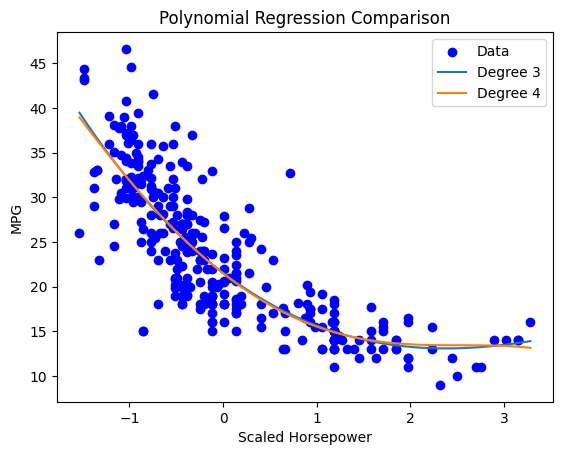

In [18]:
X_range=np.linspace(X_train_scaled.min(),X_train_scaled.max(),100).reshape(-1,1)

poly3_range=poly3_model.predict(poly3.transform(X_range))
poly4_range=poly4_model.predict(poly4.transform(X_range))

plt.scatter(X_train_scaled, y_train, color='blue', label='Data')
plt.plot(X_range,poly3_range , label='Degree 3')
plt.plot(X_range,poly4_range , label='Degree 4')
plt.xlabel("Scaled Horsepower")
plt.ylabel("MPG")

plt.legend()
plt.title("Polynomial Regression Comparison")
plt.show()